# Introduction to Convolutional Networks

This notebook introduces **convolutional neural networks (CNNs)** in the same spirit as the earlier deep learning notebooks: start from the basic operation, make the geometry explicit, and only then build a practical model in PyTorch. In the course syllabus, CNNs appear as the next step after multilayer perceptrons because they solve a problem that dense networks handle poorly: **data with spatial structure**.

A fully connected network treats every input coordinate as unrelated to every other coordinate. That is reasonable for a short feature vector, but it is wasteful for gridded Earth science data such as satellite imagery, radar reflectivity, precipitation maps, sea-surface temperature fields, or segmentation masks. In those settings, nearby pixels are related, the same spatial patterns can appear in many locations, and we want the model to detect those patterns without relearning them separately at every pixel.

CNNs build those assumptions directly into the architecture:

1. **Locality** — filters look at small neighborhoods rather than the whole image at once
2. **Weight sharing** — the same filter is reused across the domain
3. **Translation equivariance** — shifting a feature in the input shifts the response in the output
4. **Hierarchical representation** — early layers detect edges or blobs; deeper layers combine them into larger structures

The goal is not just to use `nn.Conv2d`, but to understand why convolution is a useful inductive bias for spatial Earth-system data, and how we can build intuition for the architecture by starting from the mathematical operation and working up to a practical model.

*Note: At this point if you are still note familiar with the object oriented model of PyTorch, you may want to review the following*:
- https://realpython.com/python3-object-oriented-programming/
- https://docs.pytorch.org/tutorials/index.html


___

In [ ]:
! wget -q https://github.com/theevann/webconf-pytorch-workshop/raw/master/figures/image-city.jpg

In [7]:
import sys
from collections import OrderedDict
from matplotlib import pyplot as plt

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision.transforms.functional import to_tensor, to_pil_image

torch.set_printoptions(precision=3)

# What is a convolution ?

### The 1D convolution

Given a signal $x[n]$ and a kernel (filter) $k[m]$ of length $M$, the (cross-correlation) convolution is:

$$y[n] = \sum_{m=0}^{M-1} k[m] \cdot x[n + m]$$

Two classic examples:
- **Moving average**: $k = [1/3, 1/3, 1/3]$ — smooths the signal, suppresses high-frequency noise
- **Finite difference**: $k = [-1, 0, 1]$ — approximates the derivative, detects edges/gradients

### The 2D convolution
For a single-channel image $X \in \mathbb{R}^{H \times W}$ and a kernel $K \in \mathbb{R}^{k_h \times k_w}$, a 2D convolution layer computes

$$
Y_{ij} = \sum_{a=1}^{k_h} \sum_{b=1}^{k_w} K_{ab}\,X_{i+a-1,\,j+b-1}
$$

at each spatial location $(i,j)$.

In deep learning libraries this is usually implemented as **cross-correlation** rather than the signal-processing convention that flips the kernel. For intuition, that distinction is not important: the kernel is still a learnable local pattern detector.



## 1D Convolution

A convolution is an operation between two signals.  
In computer vision, one signal is usually the **input** (audio signal, image, ...), while the other signal is called **filter** or **kernel**.

To get the convolution output of an input vector and a kernel:
- **Slide the kernel** at each different possible positions in the input
- For each position, perform the **element-wise product** between the kernel and the corresponding part of the input
- **Sum** the result of the element-wise product

![convolution 1d](https://github.com/theevann/webconf-pytorch-workshop/blob/master/figures/conv-1d.gif?raw=1)

We can perform this operation in PyTorch using the `conv_1d` function.

In [8]:
input = torch.Tensor([1,4,-1,0,2,-2,1,3,3,1]).view(1,1,-1)  # Size: (Batch size, Num Channels, Input size)
kernel = torch.Tensor([1,2,0,-1]).view(1,1,-1)  # Size: (Num output channels, Num input channels, Kernel size)

torch.nn.functional.conv1d(input, kernel)

tensor([[[ 9.,  0.,  1.,  3., -5., -3.,  6.]]])

## Or shown in a continuous fashion

![img](https://upload.wikimedia.org/wikipedia/commons/6/6a/Convolution_of_box_signal_with_itself2.gif)

![img2](https://upload.wikimedia.org/wikipedia/commons/b/b9/Convolution_of_spiky_function_with_box2.gif)

## 2D Convolution

The extension to 2D is straightforward: the operation is similar, but now input and kernel are both 2-dimensional.

![convolution 2d](https://github.com/theevann/webconf-pytorch-workshop/blob/master/figures/conv-2ds.gif?raw=1)

We can perform this operation in PyTorch using the `conv_2d` function.

In [9]:
# Input Size: (Batch size, Num channels, Input height, Input width)
input = torch.Tensor([[3,3,2,1,0], [0,0,1,3,1], [3,1,2,2,3], [2,0,0,2,2], [2,0,0,0,1]]).view(1,1,5,5)

# Kernel Size: (Num output channels, Num input channels, Kernel height, Kernel width)
kernel = torch.Tensor([[0,1,2],[2,2,0],[0,1,2]]).view(1,1,3,3)

torch.nn.functional.conv2d(input, kernel)

tensor([[[[12., 12., 17.],
          [10., 17., 19.],
          [ 9.,  6., 14.]]]])

## Multiple channels

You can use have multiple channels in input. A color image usually have 3 input channels : RGB.  
Therefore, the kernel will also have channels, one for each input channel.

<img src="https://github.com/theevann/webconf-pytorch-workshop/blob/master/figures/conv-2d-in-channels.gif?raw=1" alt="drawing" width="700"/>

You can use multiple different kernels. The number of output channels corresponds to the number of kernel you use.

<img src="https://github.com/theevann/webconf-pytorch-workshop/blob/master/figures/conv-2d-out-channels.gif?raw=1" alt="drawing" width="400"/>

## Trying on a real image

(600, 348)


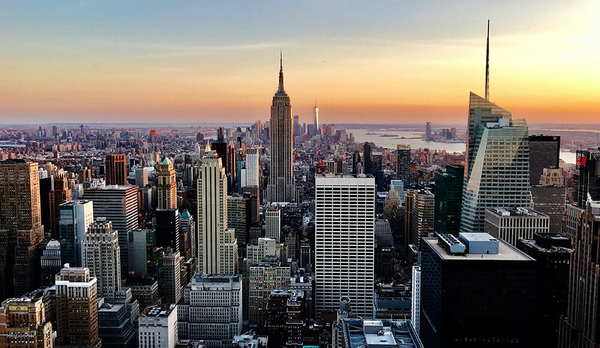

In [10]:
from PIL import Image

image = Image.open("image-city.jpg")
print(image.size)
image

We will use a boundary detector filter as kernel:

$$\begin{bmatrix}
-1 & 0 & 1 \\
-1 & 0 & 1 \\
-1 & 0 & 1
\end{bmatrix}
$$

Pay attention to the dimensions of the input and the kernel:
- Input Size: **Batch size** x **Num channels** x **Input height** x **Input width**
- Kernel Size: **Num output channels** x **Num input channels** x **Kernel height** x **Kernel width**

Note:
- There are 3 input channels (since we have an rgb image)
- In output, we want only one channel (ie. we define only one kernel)
- Here, batch size will be 1.

In [13]:
image_tensor = to_tensor(image)
input = image_tensor.unsqueeze(0)
kernel = torch.Tensor([-1,0,1]).expand(1,3,3,3)

out =  torch.nn.functional.conv2d(input, kernel)

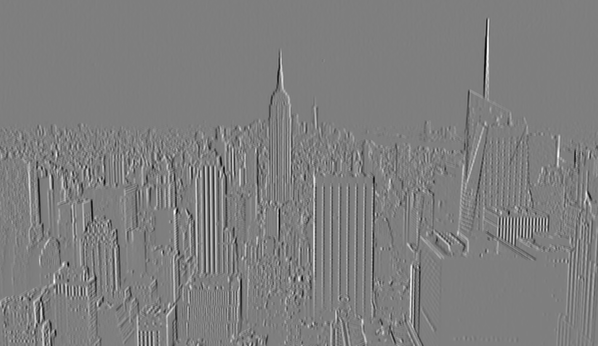

In [14]:
norm_out = (out - out.min()) / (out.max() - out.min())  # Map output to [0,1] for visualisation purposes
to_pil_image(norm_out.squeeze())

# Another example of edge detection
We start with a toy image and two hand-designed kernels:

- a **vertical-edge detector**
- a **horizontal-edge detector**

This is the simplest way to see what a feature map is.

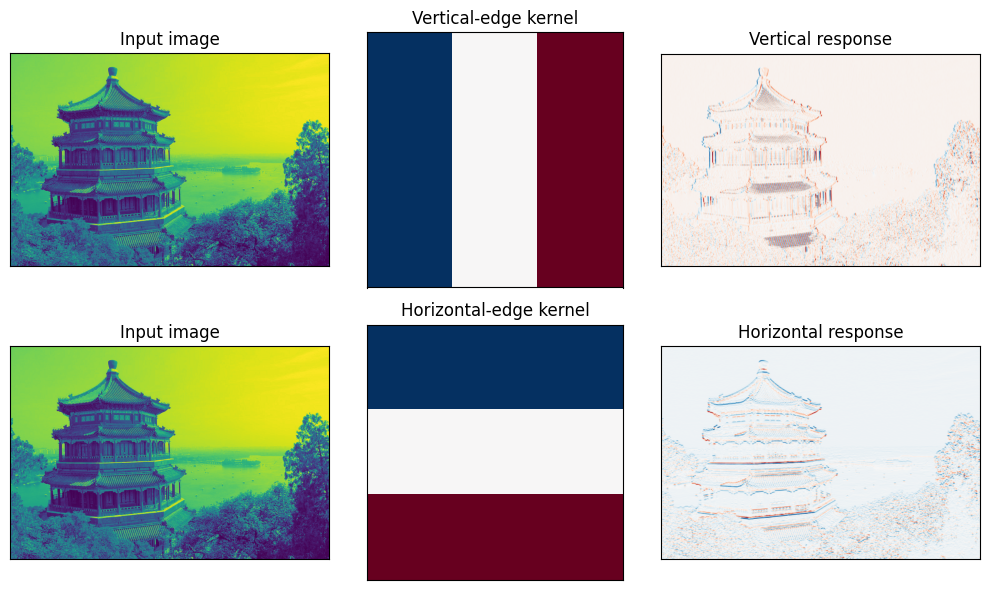

In [15]:
def conv2d_single_channel(image, kernel, padding=0, stride=1):
    """Naive 2D cross-correlation for a single channel image."""
    image = np.asarray(image, dtype=float)
    kernel = np.asarray(kernel, dtype=float)

    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')

    kh, kw = kernel.shape
    out_h = (image.shape[0] - kh) // stride + 1
    out_w = (image.shape[1] - kw) // stride + 1
    out = np.zeros((out_h, out_w), dtype=float)

    for i in range(out_h):
        for j in range(out_w):
            patch = image[i*stride:i*stride+kh, j*stride:j*stride+kw]
            out[i, j] = np.sum(patch * kernel)
    return out

from sklearn.datasets import load_sample_image

# Load a sample image and convert to grayscale
china = load_sample_image("china.jpg")
# Convert to grayscale using luminosity formula
image = np.dot(china[..., :3], [0.2989, 0.5870, 0.1140])


vertical_kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1],
], dtype=float)

horizontal_kernel = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1],
], dtype=float)

vert_response = conv2d_single_channel(image, vertical_kernel, padding=0)
horiz_response = conv2d_single_channel(image, horizontal_kernel, padding=0)

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

axes[0, 0].imshow(image, cmap='viridis')
axes[0, 0].set_title('Input image')
axes[0, 1].imshow(vertical_kernel, cmap='RdBu_r')
axes[0, 1].set_title('Vertical-edge kernel')
axes[0, 2].imshow(vert_response, cmap='RdBu_r')
axes[0, 2].set_title('Vertical response')

axes[1, 0].imshow(image, cmap='viridis')
axes[1, 0].set_title('Input image')
axes[1, 1].imshow(horizontal_kernel, cmap='RdBu_r')
axes[1, 1].set_title('Horizontal-edge kernel')
axes[1, 2].imshow(horiz_response, cmap='RdBu_r')
axes[1, 2].set_title('Horizontal response')

plt.tight_layout()
plt.show()



## Convolutions in `nn.Module`

When using a convolution layer inside an `nn.Module`, we rather use the `nn.Conv2d` module.  
The kernels of the convolution are directly instantiated by `nn.Conv2d`.

In [16]:
conv_1 = nn.Conv2d(in_channels=3, out_channels=2, kernel_size=(3,3))

print("Convolution", conv_1)
print("Kernel size: ", conv_1.weight.shape) # First two dimensions are: Num output channels and Num input channels

Convolution Conv2d(3, 2, kernel_size=(3, 3), stride=(1, 1))
Kernel size:  torch.Size([2, 3, 3, 3])


In [ ]:
# Fake 5x5 input with 3 channels
input = torch.randn(1, 3, 5, 5)  # batch_size, num_channels, height, width

out = conv_1(input)
print(out)

_Animations credits: Francois Fleuret, Vincent Dumoulin_

# Building a CNN

We will use the MNIST classification dataset again as our learning task. However, this time we will try to solve it using Convolutional Neural Networks. Let's build the LeNet-5 CNN with PyTorch !

## Defining the LeNet-5 architecture

![](https://pytorch.org/tutorials/_images/mnist.png)

*Y. LeCun, L. Bottou, Y. Bengio, and P. Haffner. "Gradient-based learning applied to document recognition." Proceedings of the IEEE, 86(11):2278-2324, November 1998.*

In [17]:
class LeNet5(nn.Module):
    """LeNet-5 architecture for MNIST digit classification.
    
    Architecture:
        Input (1x32x32) -> Conv1 (6@28x28) -> Pool (6@14x14) -> 
        Conv2 (16@10x10) -> Pool (16@5x5) -> Conv3 (120@1x1) -> 
        FC1 (84) -> FC2 (10)
    
    Original paper: LeCun et al., 1998
    """
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=0)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, stride=1, padding=0)
        
        # Fully connected layers
        self.fc1 = nn.Linear(120, 84)
        self.fc2 = nn.Linear(84, num_classes)
        
    def forward(self, x):
        # Conv1 -> ReLU -> AvgPool (original used tanh and subsampling)
        x = F.avg_pool2d(F.relu(self.conv1(x)), kernel_size=2, stride=2)
        
        # Conv2 -> ReLU -> AvgPool
        x = F.avg_pool2d(F.relu(self.conv2(x)), kernel_size=2, stride=2)
        
        # Conv3 -> ReLU
        x = F.relu(self.conv3(x))
        
        # Flatten for fully connected layers
        x = x.view(x.size(0), -1)  # or x.flatten(1)
        
        # FC1 -> ReLU
        x = F.relu(self.fc1(x))
        
        # FC2 -> Log Softmax for numerical stability with NLLLoss
        # or use raw logits with CrossEntropyLoss
        x = F.log_softmax(self.fc2(x), dim=1)
        
        return x

An extensive list of all available layer types can be found on https://pytorch.org/docs/stable/nn.html.

### Print a network summary

In [30]:
conv_net = LeNet5()
print(conv_net)

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (conv3): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=120, out_features=84, bias=True)
  (fc2): Linear(in_features=84, out_features=10, bias=True)
)


### Retrieve trainable parameters

In [31]:
named_params = list(conv_net.named_parameters())
print("len(params): %s\n" % len(named_params))

for name, param in named_params:
    print("%s:\t%s" % (name, param.shape))

len(params): 10

conv1.weight:	torch.Size([6, 1, 5, 5])
conv1.bias:	torch.Size([6])
conv2.weight:	torch.Size([16, 6, 5, 5])
conv2.bias:	torch.Size([16])
conv3.weight:	torch.Size([120, 16, 5, 5])
conv3.bias:	torch.Size([120])
fc1.weight:	torch.Size([84, 120])
fc1.bias:	torch.Size([84])
fc2.weight:	torch.Size([10, 84])
fc2.bias:	torch.Size([10])


### Feed network with a random input

In [32]:
input = torch.randn(1, 1, 32, 32)  # batch_size, num_channels, height, width
out = conv_net(input)
print("Log-Probabilities: \n%s\n" % out)
print("Probabilities: \n%s\n" % torch.exp(out))
print("out.shape: \n%s" % (out.shape,))

Log-Probabilities: 
tensor([[-2.378, -2.397, -2.280, -2.185, -2.270, -2.234, -2.398, -2.327, -2.270,
         -2.310]], grad_fn=<LogSoftmaxBackward0>)

Probabilities: 
tensor([[0.093, 0.091, 0.102, 0.112, 0.103, 0.107, 0.091, 0.098, 0.103, 0.099]],
       grad_fn=<ExpBackward0>)

out.shape: 
torch.Size([1, 10])


---

# Training our CNN

### Train function

Similarly to the previous notebook, we define a train function `train_cnn`.

In [33]:
def train_cnn(model, train_loader, test_loader, device, num_epochs=3, lr=0.1):

    # define an optimizer and a loss function
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        print("=" * 40, "Starting epoch %d" % (epoch + 1), "=" * 40)

        model.train()  # Not necessary in our example, but still good practice.
                       # Only models with nn.Dropout and nn.BatchNorm modules require it

        # dataloader returns batches of images for 'data' and a tensor with their respective labels in 'labels'
        for batch_idx, (data, labels) in enumerate(train_loader):
            data, labels = data.to(device), labels.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()

            if batch_idx % 40 == 0:
                print("Batch %d/%d, Loss=%.4f" % (batch_idx, len(train_loader), loss.item()))

        # Compute the train and test accuracy at the end of each epoch
        train_acc = accuracy(model, train_loader, device)
        test_acc = accuracy(model, test_loader, device)

        print("\nAccuracy on training: %.2f%%" % (100*train_acc))
        print("Accuracy on test: %.2f%%" % (100*test_acc))

### Test function
We also define an `accuracy` function which can evaluate our model's accuracy on train/test data

In [34]:
def accuracy(model, dataloader, device):
    """ Computes the model's accuracy on the data provided by 'dataloader'
    """
    model.eval()

    num_correct = 0
    num_samples = 0
    with torch.no_grad():  # deactivates autograd, reduces memory usage and speeds up computations
        for data, labels in dataloader:
            data, labels = data.to(device), labels.to(device)

            predictions = model(data).max(1)[1]  # indices of the maxima along the second dimension
            num_correct += (predictions == labels).sum().item()
            num_samples += predictions.shape[0]

    return num_correct / num_samples

### Loading the train and test data with *`dataloaders`*

In [35]:
from torchvision import datasets, transforms

transformations = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

train_data = datasets.MNIST('./data',
                            train = True,
                            download = True,
                            transform = transformations)

test_data = datasets.MNIST('./data',
                            train = False,
                            download = True,
                            transform = transformations)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=256, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=1024, shuffle=False)

### Start the training!

In [36]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
conv_net.to(device)

train_cnn(conv_net, train_loader, test_loader, device, lr=2e-3)

======================================== Starting epoch 1 ========================================
Batch 0/235, Loss=2.3066
Batch 40/235, Loss=0.4808
Batch 80/235, Loss=0.3981
Batch 120/235, Loss=0.3040
Batch 160/235, Loss=0.2674
Batch 200/235, Loss=0.2242

Accuracy on training: 94.35%
Accuracy on test: 94.54%
======================================== Starting epoch 2 ========================================
Batch 0/235, Loss=0.1731
Batch 40/235, Loss=0.1592
Batch 80/235, Loss=0.1422
Batch 120/235, Loss=0.0719
Batch 160/235, Loss=0.0574
Batch 200/235, Loss=0.1028

Accuracy on training: 97.61%
Accuracy on test: 97.73%
======================================== Starting epoch 3 ========================================
Batch 0/235, Loss=0.1797
Batch 40/235, Loss=0.0509
Batch 80/235, Loss=0.0520
Batch 120/235, Loss=0.0668
Batch 160/235, Loss=0.0423
Batch 200/235, Loss=0.0651

Accuracy on training: 98.25%
Accuracy on test: 98.16%


### Let's look at some of the model's predictions

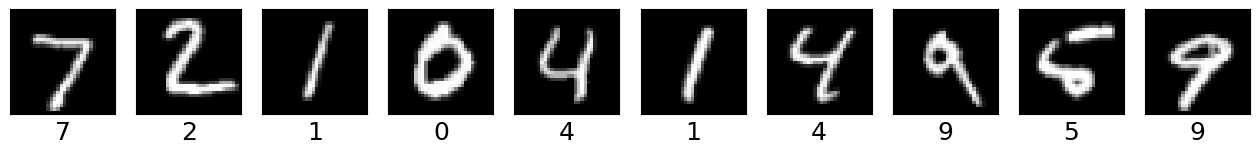

In [37]:
def visualize_predictions(model, dataloader, device):
    data, labels = next(iter(dataloader))
    data, labels = data[:10].to(device), labels[:10]
    predictions = model(data).max(1)[1]

    predictions, data = predictions.cpu(), data.cpu()

    plt.figure(figsize=(16,9))
    for i in range(10):
        img = data.squeeze(1)[i]
        plt.subplot(1, 10, i+1)
        plt.imshow(img, cmap="gray", interpolation="none")
        plt.xlabel(predictions[i].item(), fontsize=18)
        plt.xticks([])
        plt.yticks([])

visualize_predictions(conv_net, test_loader, device)

(6, 5, 5)


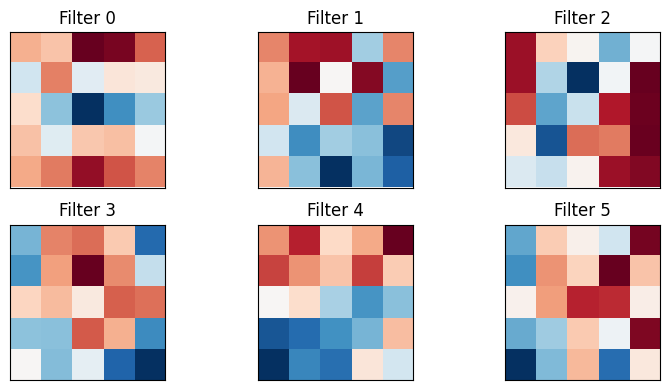

In [40]:
weights = conv_net.conv1.weight.detach().numpy()[:, 0]
print(weights.shape)
fig, axes = plt.subplots(2, 3, figsize=(8, 4))
for ax, w, i in zip(axes.ravel(), weights, range(len(weights))):
    im = ax.imshow(w, cmap='RdBu_r')
    ax.set_title(f'Filter {i}')
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

# Variants of ConvNets + some history

### LeCun and Backpropagation (Late 1980s–90s) - the LeNet-5 architecture
The field took a major leap when Yann LeCun and colleagues at Bell Labs applied backpropagation to train convolutional networks, resulting in LeNet (1989, refined through the 1990s). LeNet was used commercially to read handwritten zip codes and checks, demonstrating for the first time that CNNs could solve real-world problems at scale. The 1998 paper Gradient-Based Learning Applied to Document Recognition became a foundational reference for the field.

### The Deep Learning Revolution (2012)
In 2012 Alex Krizhevsky, Ilya Sutskever, and Geoffrey Hinton entered AlexNet into the ImageNet Large Scale Visual Recognition Challenge (ILSVRC). AlexNet dramatically outperformed all competitors, cutting the top-5 error rate nearly in half. It achieved this through several key innovations: training on GPUs, using ReLU activations instead of sigmoid functions, and applying dropout regularization to combat overfitting. This moment is widely regarded as the beginning of the modern deep learning era.

### Deeper learning VGGnet, ResNet, and beyond
The years following AlexNet saw a rapid series of architectural advances. ZFNet (2013) refined AlexNet's design with better visualization techniques. VGGNet (2014) from Oxford showed the power of depth using very small (3×3) convolutional filters stacked in sequence. GoogLeNet / Inception (2014) introduced the "inception module," enabling much greater depth and width while keeping computation manageable.

The problem of training very deep networks — gradients vanishing or exploding over many layers — was elegantly solved by Microsoft Research's ResNet (2015), which introduced skip connections (residual connections) allowing gradients to flow directly across layers. ResNet enabled networks over 100 layers deep and won ImageNet that year by a wide margin. Subsequent architectures like DenseNet, SENet, EfficientNet, and MobileNet continued refining the ideas of depth, efficiency, and scalability.

### UNet and segmentation
For pixel-wise tasks like segmentation, the UNet architecture (2015) became a standard.
UNet's "U-shaped" design combines a contracting path (encoder) that captures context with an expansive path (decoder) that enables precise localization. Skip connections between corresponding layers in the encoder and decoder allow the network to leverage both high-level features and fine-grained details, making it particularly effective for medical image segmentation and other applications where spatial precision is crucial.

### Are ConvNets still relevant?
More recently, Vision Transformers (ViTs) have challenged CNN dominance in certain tasks, applying the self-attention mechanisms of NLP transformers to image patches. Hybrid architectures now often blend convolutional and attention-based components. Still, CNNs remain foundational — embedded in smartphones, medical imaging systems, autonomous vehicles, and countless other applications. Their development stands as one of the most consequential arcs in the history of artificial intelligence.
